* ! işareti → Jupyter Notebook / Colab içinde terminal komutu çalıştırır.
* pip install → gerekli Python kütüphanelerini yükler.
* pandas → veri okuma ve tablo işlemleri için.
* numpy → sayısal işlemler için.
* seaborn → gelişmiş grafikler için.

In [1]:
!pip install pandas numpy seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
# pandas kütüphanesini projeye dahil eder.
# pd kısa adıyla kullanılır.
import matplotlib.pyplot as plt  # Grafik çizmek için kullanılan matplotlib kütüphanesinin pyplot modülünü içe aktarır.
import seaborn as sns  # seaborn veri görselleştirme kütüphanesini içe aktarır.


In [3]:
df = pd.read_csv('data_cleaned.csv')

* data_cleaned.csv dosyasını okur.
* Veriyi DataFrame’e yükler.
* Sonuç df değişkenine atanır.

In [4]:
sns.set_theme(style="darkgrid")   # Seaborn’un grafik temasını ayarlar. 
# darkgrid → koyu arkaplan + ızgaralı görünüm.
plt.rcParams['figure.figsize'] = (10, 6) # Tüm grafiklerin varsayılan boyutunu ayarlar.
# genişlik = 10   yükseklik = 6
# Her grafikte tekrar figsize yazmamak için kullanılır.
print("Hazır!", df.shape)  #veri boyutu yazdırır.

Hazır! (113999, 21)


In [5]:
mood_colors = {
    'happy': '#F9CB42',
    'calm':  '#1D9E75',
    'angry': '#D85A30',
    'sad':   '#378ADD'
}

Duygular için özel renk tanımlıyor.

| Mood  | Renk            |
| ----- | --------------- |
| happy | sarı            |
| calm  | yeşil           |
| angry | turuncu/kırmızı |
| sad   | mavi            |

Grafiklerde aynı renkler kullanılacak.

In [6]:
counts = df['mood'].value_counts()

Her mood’dan kaç tane olduğunu sayar.

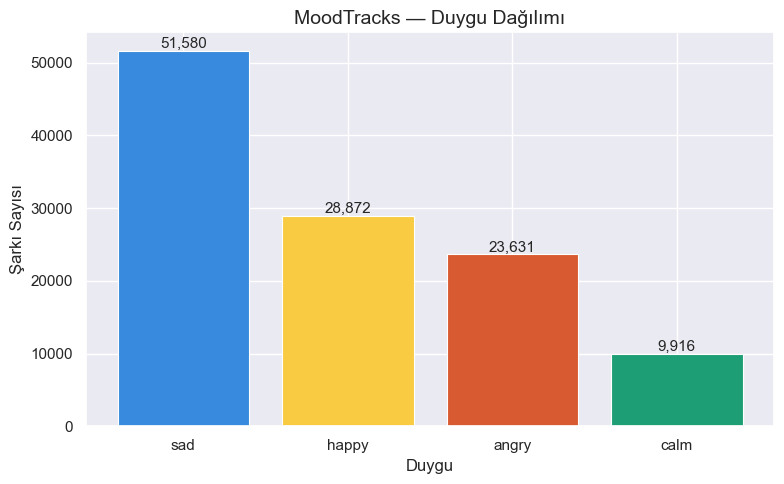

In [7]:
plt.figure(figsize=(8, 5))
# Yeni bir grafik alanı oluşturur.
# Boyut: genişlik = 8 yükseklik = 5
bars = plt.bar(counts.index, counts.values,    # Çubuk grafik oluşturur.
               color=[mood_colors[m] for m in counts.index],
               edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 400,
             f'{val:,}', ha='center', fontsize=11)

plt.title('MoodTracks — Duygu Dağılımı', fontsize=14)  # Grafik başlığı.
plt.xlabel('Duygu')  # Alt eksen adı.
plt.ylabel('Şarkı Sayısı') # Sol eksen adı.
plt.tight_layout() # Yazıların taşmasını önler.
plt.savefig('mood_distribution.png', dpi=150) # Grafiği PNG olarak kaydeder.
plt.show()  # Grafiği ekrana basar.

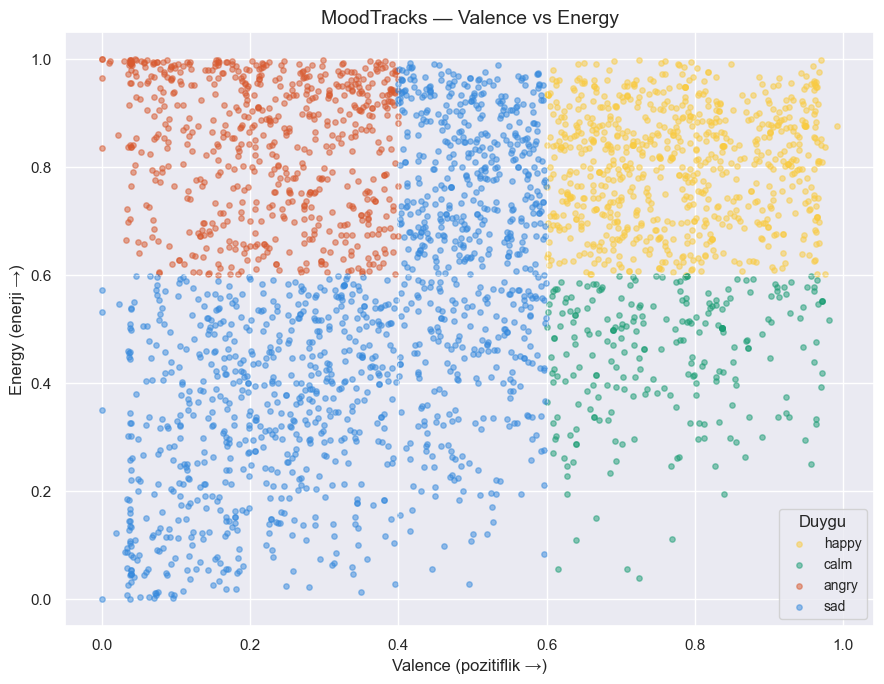

In [8]:
sample = df.sample(3000, random_state=42)  # Veriden rastgele 3000 şarkı seçer.

plt.figure(figsize=(9, 7))  # Yeni grafik oluşturur.
for mood, color in mood_colors.items():  # Tüm mood’ları dolaşır.
    mask = sample['mood'] == mood  # Sadece o duyguya ait satırları seçer.
    plt.scatter(sample[mask]['valence'],   # Nokta grafiği oluşturur.
                sample[mask]['energy'],
                c=color, label=mood,
                alpha=0.5, s=15)

# Sınır çizgileri
plt.axvline(x=0.6, color='white', linewidth=0.8, linestyle='--', alpha=0.6) # Dikey çizgi çizer.
plt.axvline(x=0.4, color='white', linewidth=0.8, linestyle='--', alpha=0.6) # İkinci dikey çizgi.
plt.axhline(y=0.6, color='white', linewidth=0.8, linestyle='--', alpha=0.6) # Yatay çizgi.

plt.title('MoodTracks — Valence vs Energy', fontsize=14) # Scatter plot başlığı.
plt.xlabel('Valence (pozitiflik →)')
plt.ylabel('Energy (enerji →)')
plt.legend(title='Duygu', fontsize=10) # Sağ üstte açıklama kutusu oluşturur.
plt.tight_layout()
plt.savefig('valence_energy_scatter.png', dpi=150)
plt.show()

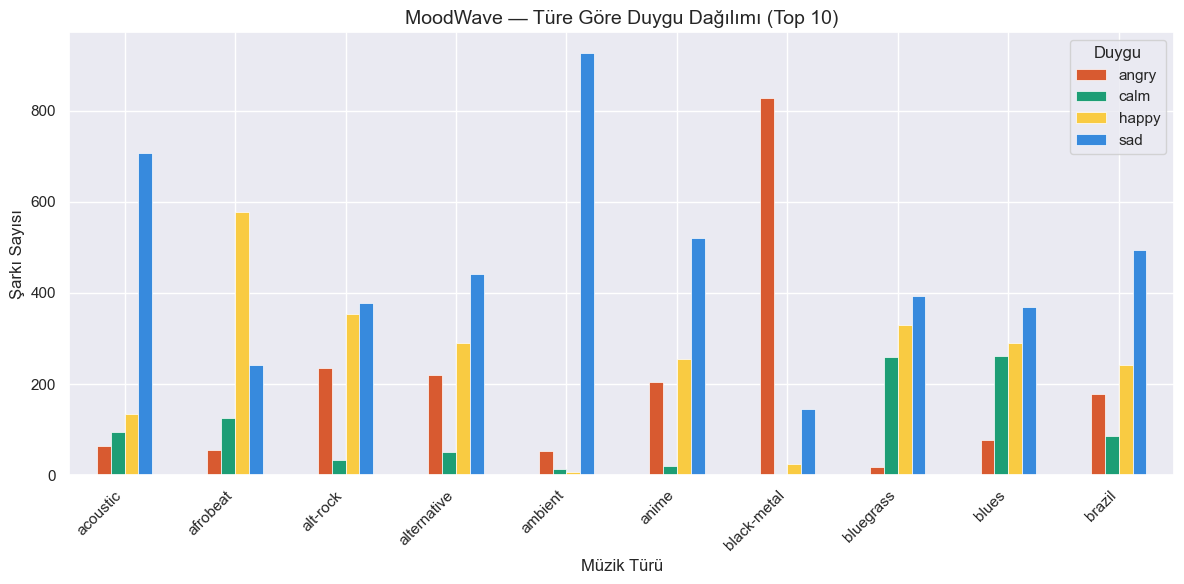

In [9]:
top10_genres = df['track_genre'].value_counts().head(10).index  # En fazla bulunan ilk 10 müzik türünü alır.
df_top10 = df[df['track_genre'].isin(top10_genres)] # Sadece top 10 türleri bırakır.

pivot = df_top10.groupby(['track_genre', 'mood']).size().unstack(fill_value=0)

pivot.plot(kind='bar', figsize=(12, 6),  # Türlere göre mood dağılımını çizer.
           color=[mood_colors[m] for m in pivot.columns],
           edgecolor='white', linewidth=0.5)

plt.title('MoodWave — Türe Göre Duygu Dağılımı (Top 10)', fontsize=14)
plt.xlabel('Müzik Türü')
plt.ylabel('Şarkı Sayısı')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Duygu')
plt.tight_layout()
plt.savefig('genre_mood.png', dpi=150)
plt.show()

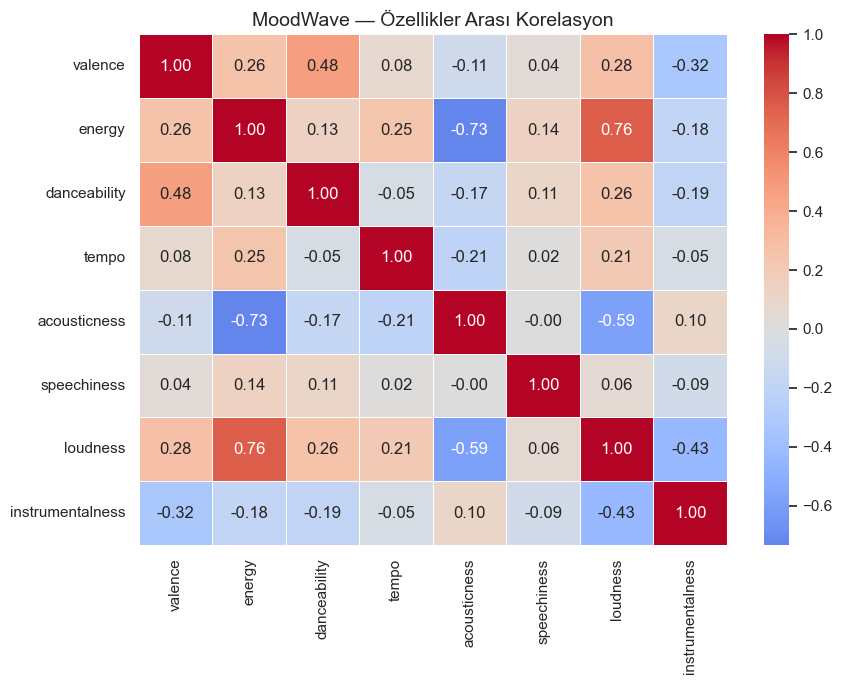

In [10]:
features = ['valence', 'energy', 'danceability', 'tempo',    
            'acousticness', 'speechiness', 'loudness', 'instrumentalness'] 
# Korelasyon analizinde kullanılacak sütunlar.

corr = df[features].corr() # Özellikler arasındaki ilişkiyi hesaplar.

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, linewidths=0.5, linecolor='white')
# Korelasyon ısı haritası oluşturur.
plt.title('MoodWave — Özellikler Arası Korelasyon', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show() # Heatmap’i ekrana basar.